<a href="https://colab.research.google.com/github/nevita275/ML_20_Nevita/blob/main/JS06/JS06-02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KALSIFIKASI 2
# LAB 2
## Langkah 1 - Ilustrasi Data Non-Linier
### Langkah 1a - Import Library

In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.svm import SVC

### Langkah 1b - Buat Kembali Fungsi Plotting

In [2]:
# buat sebuah fungsi untuk menampilkan fitting data

def plot_svc_decision_function(model, ax=None, plot_support=True):

	  if ax is None:
	      ax = plt.gca()
	  xlim = ax.get_xlim()
	  ylim = ax.get_ylim()

	  # buat grid untuk evaluasi model
	  x = np.linspace(xlim[0], xlim[1], 30)
	  y = np.linspace(ylim[0], ylim[1], 30)
	  Y, X = np.meshgrid(y, x)
	  xy = np.vstack([X.ravel(), Y.ravel()]).T
	  P = model.decision_function(xy).reshape(X.shape)

	  # plot batas dan margin
	  ax.contour(X, Y, P, colors='k',
	              levels=[-1, 0, 1], alpha=0.5,
	              linestyles=['--', '-', '--'])

	  # plot support vectors
	  if plot_support:
	      ax.scatter(model.support_vectors_[:, 0],
	                  model.support_vectors_[:, 1],
	                  s=300, linewidth=1, facecolors='none');
	  ax.set_xlim(xlim)
	  ax.set_ylim(ylim)

### Langkah 1c - Buat Data Dummy Non-Linier

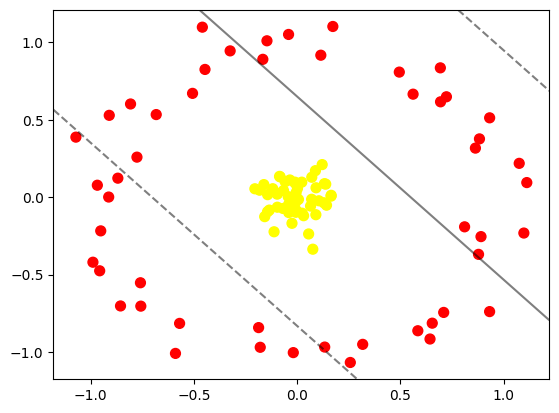

In [16]:
# contoh data tidak terpisah secara linier
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

### Langkah 1d - Proyeksi Radial

In [17]:
r = np.exp(-(X**2).sum(1))

In [18]:
from mpl_toolkits import mplot3d
from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
	  ax = plt.subplot(projection='3d')
	  ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	  ax.view_init(elev=elev, azim=azim)
	  ax.set_xlabel('x')
	  ax.set_ylabel('y')
	  ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	        X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-8.06971174e-01,  6.02020359e-01],
       [-1.34926021e-01, -8.33682250e-02],
       [-6.40303525e-03, -9.75382835e-02],
       [-1.86777679e-01, -8.42356643e-01],
       [ 9.31827955e-01, -7.38995551e-01],
       [-4.09549894e-02, -9.91497481e-02],
       [-3.24652911e-01,  9.45000332e-01],
       [ 9.04339786e-02, -1.13189924e-01],
       [ 1.05001052e-01, -2.32259966e-02],
       [ 8.90120150e-01, -2.54716680e-01],
       [-2.51993251e-02, -1.68687412e-01],
       [-1.08247282e-02,  9.71282918e-02],
       [-9.68747909e-02,  1.95768341e-02],
       [-1.82208683e-01,  4.51303156e-02],
       [ 7.00205076e-02, -1.34259131e-02],
       [ 8.78220365e-01, -3.69242963e-01],
       [ 9.32024293e-01,  5.12608847e-01],
       [ 5.61232393e-01,  6.65396057e-01],
       [-4.46442729e-01,  8.25149278e-01],
       [ 5.54658549e-02, -2.37480769e-01],
       [ 6.47687871e-02, -5.73937486e-02],
       [ 1.42008369e-01, -5.17593323e-02],
       [ 1.29207645e-01, -3.59188117e-02],
       [ 5.84221053e-01, -8.62687435e-01],
       [-5.69409691e-01, -8.15185209e-01],
       [-6.83509116e-02, -7.28980180e-02],
       [-6.82639964e-01,  5.33632763e-01],
       [ 8.82870080e-02,  1.71296100e-01],
       [ 9.13014063e-02,  6.07384895e-02],
       [-1.78935980e-01, -9.69521321e-01],
       [-9.12777771e-01,  9.71515857e-04],
       [-9.56383917e-01, -4.75468573e-01],
       [-4.59270831e-01,  1.09811515e+00],
       [ 1.21027226e-01,  2.10472012e-01],
       [-9.89148291e-01, -4.20044207e-01],
       [ 1.64605036e-01,  1.21269893e-02],
       [-3.54682548e-02,  1.11104542e-01],
       [ 1.72669512e-01,  1.10263584e+00],
       [-8.54048385e-02,  1.34471653e-01],
       [-2.04833071e-01,  5.43639410e-02],
       [-9.60989585e-02, -6.47764934e-02],
       [ 2.22745899e-02,  9.70369879e-02],
       [ 1.48736317e-03,  5.64615065e-02],
       [-8.68444808e-01,  1.22774884e-01],
       [-8.55513287e-01, -7.02557573e-01],
       [-1.46405175e-01,  1.01014773e+00],
       [-1.07161778e+00,  3.87815190e-01],
       [-1.11989332e-01, -2.23395974e-01],
       [-6.61490434e-02,  4.31278306e-02],
       [-1.43177634e-01,  1.63765360e-02],
       [-1.18326832e-01,  5.47266432e-02],
       [-1.66334633e-01,  8.90505593e-01],
       [ 8.63072146e-01,  3.16961220e-01],
       [ 7.06385193e-02,  1.28777608e-01],
       [-4.33488522e-02,  3.45073514e-03],
       [ 3.11186033e-02, -1.19587496e-01],
       [-4.24397425e-02, -4.87287369e-02],
       [ 6.93288213e-01,  8.35423947e-01],
       [ 6.43230599e-01, -9.16091525e-01],
       [-5.81040464e-02,  1.00055006e-01],
       [-5.89384554e-01, -1.00905526e+00],
       [-7.58961152e-01, -5.52712452e-01],
       [ 1.38258567e-01,  8.41977143e-02],
       [ 1.31905744e-01,  8.71413314e-02],
       [ 1.14491216e-01,  9.17043983e-01],
       [ 4.94472223e-01,  8.07981627e-01],
       [ 7.56697162e-02, -3.35970175e-01],
       [ 6.11475397e-03, -1.43475212e-02],
       [ 1.64087577e-01,  6.79154754e-03],
       [-9.67757422e-01,  7.72203559e-02],
       [-9.10075441e-01,  5.28751588e-01],
       [-5.23230031e-03,  2.95104956e-02],
       [-1.57343115e-01, -1.25671460e-01],
       [ 2.57239026e-01, -1.06764024e+00],
       [-7.80083035e-03, -3.25239255e-02],
       [-9.57240464e-02,  2.43012234e-02],
       [-4.17424928e-02,  1.05116353e+00],
       [-9.51303728e-01, -2.17553074e-01],
       [-8.25268044e-02,  1.31362020e-01],
       [-7.75966037e-01,  2.58639587e-01],
       [ 8.82711551e-01,  3.76598558e-01],
       [ 7.22687191e-01,  6.48565406e-01],
       [-9.29379854e-03,  8.97596395e-02],
       [ 6.54067539e-01, -8.13761581e-01],
       [-2.27861507e-02, -2.96331150e-02],
       [-1.61387640e-01,  8.12831227e-02],
       [-1.88560073e-02, -1.00393817e+00],
       [ 3.17235992e-01, -9.50543263e-01],
       [ 7.09494430e-01, -7.44337458e-01],
       [-5.06715870e-01,  6.70604881e-01],
       [ 1.11193033e+00,  9.43513298e-02],
       [ 1.09768221e+00, -2.31573825e-01

## Langkah 2 - Fitting Model
### Langkah 2a - Fitting Model RBF

In [19]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)

SVC(C=1000000.0)

### Langkah 2b - Plot Decision Boundary

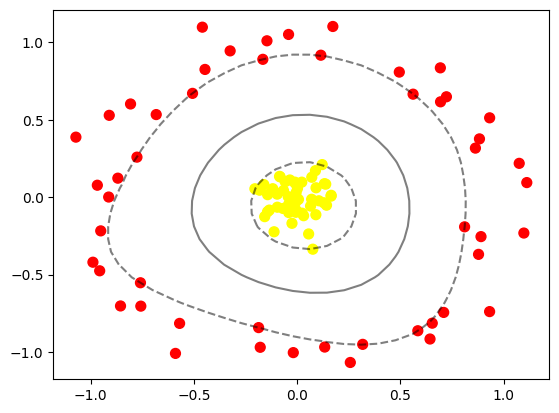

In [20]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	          s=300, lw=1, facecolors='none')